# Prac 08.2

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

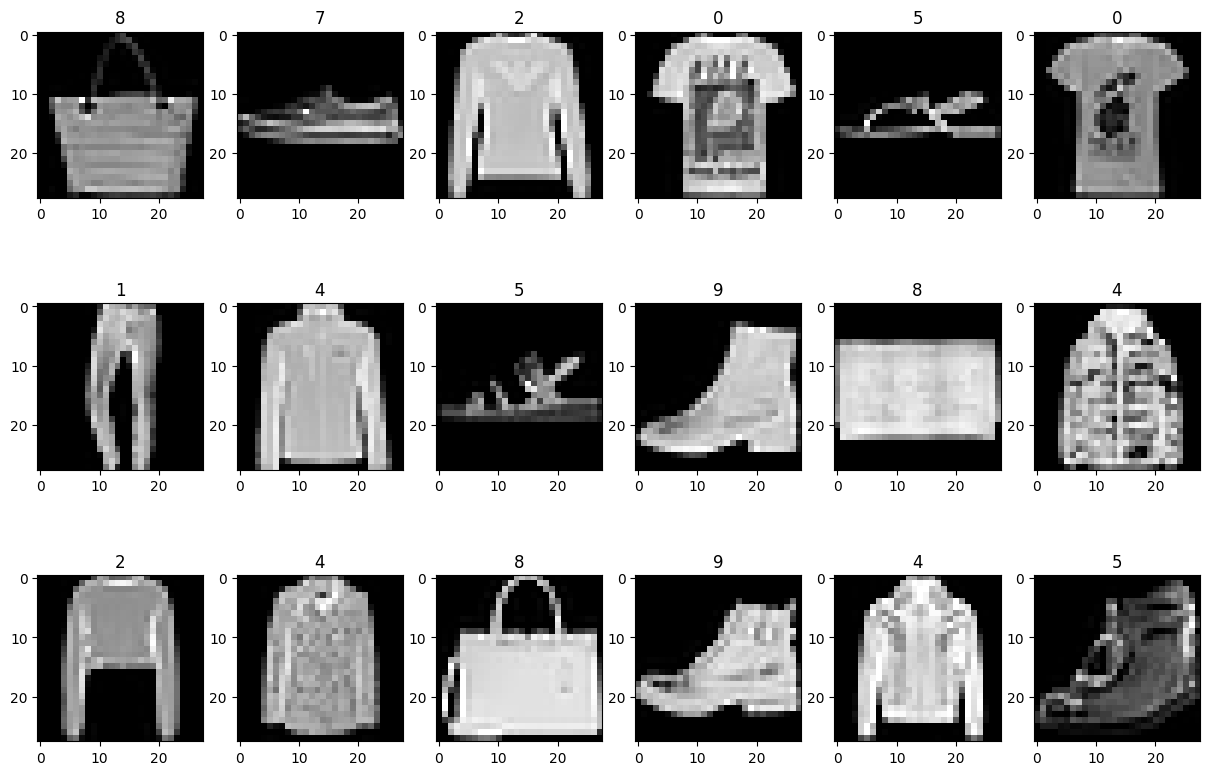

In [3]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [4]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [5]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)               3211392   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 3,213,002
Trainable params: 3,213,002
Non-trainable params: 0
_________________________________________________________________


In [6]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 [==============================] - 4s 2ms/step - loss: 0.4071 - accuracy: 0.8618 - val_loss: 0.3255 - val_accuracy: 0.8828
Epoch 2/50
938/938 [==============================] - 2s 2ms/step - loss: 0.2668 - accuracy: 0.9050 - val_loss: 0.2963 - val_accuracy: 0.8910
Epoch 3/50
938/938 [==============================] - 2s 2ms/step - loss: 0.2287 - accuracy: 0.9172 - val_loss: 0.3064 - val_accuracy: 0.8922
Epoch 4/50
938/938 [==============================] - 2s 2ms/step - loss: 0.1996 - accuracy: 0.9266 - val_loss: 0.2976 - val_accuracy: 0.9008
Epoch 5/50
938/938 [==============================] - 2s 2ms/step - loss: 0.1780 - accuracy: 0.9355 - val_loss: 0.3105 - val_accuracy: 0.8965
Epoch 6/50
938/938 [==============================] - 2s 2ms/step - loss: 0.1605 - accuracy: 0.9413 - val_loss: 0.3044 - val_accuracy: 0.8989
Epoch 7/50
938/938 [==============================] - 2s 2ms/step - loss: 0.1443 - accuracy: 0.9468 - val_loss: 0.3196 - val_accuracy: 0.8992
Epoch 

Train Acc      0.9941666722297668
Validation Acc 0.8827000260353088


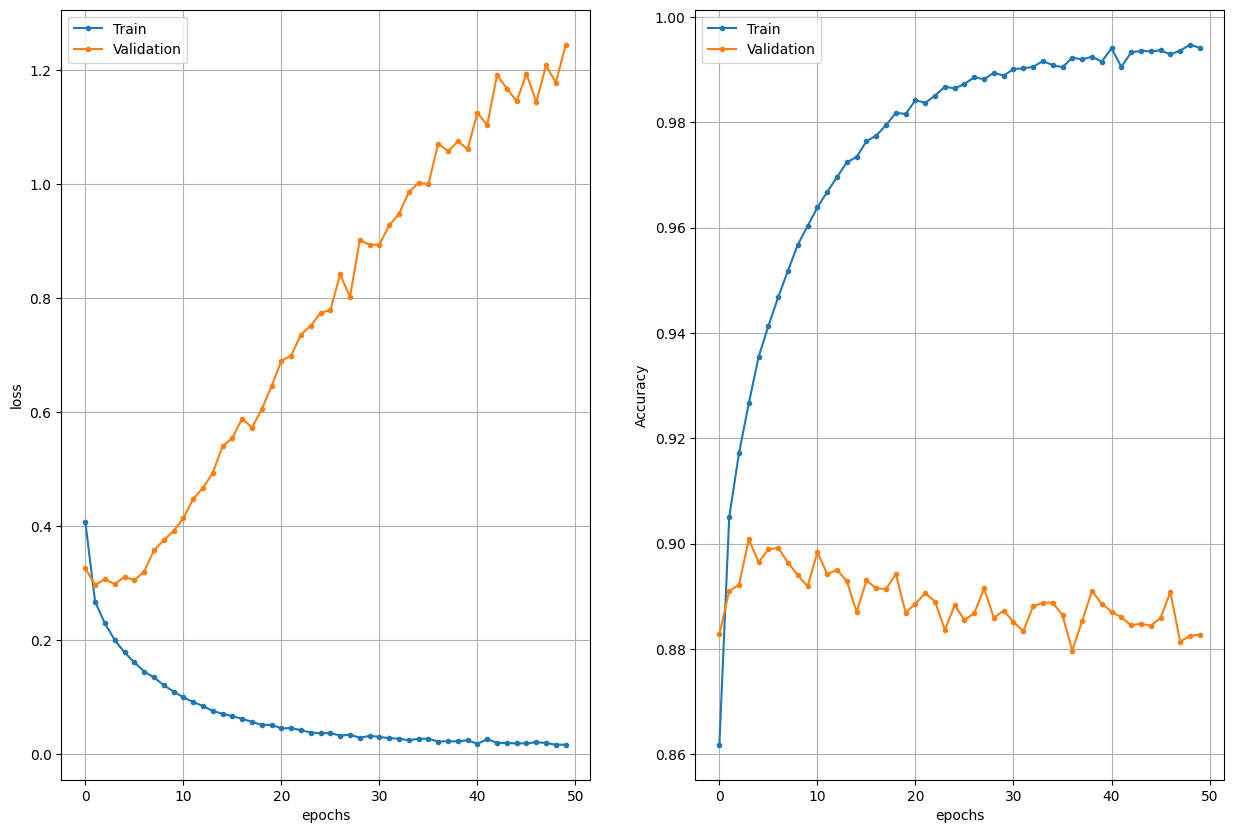

In [7]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [8]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

inputs = Input(shape=(28, 28, 1))
net = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='valid')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(256, kernel_size=(3, 3), activation="relu", padding='valid')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(512, kernel_size=(3, 3), activation="relu", padding='valid')(net)
net = Flatten()(net)
net = Dropout(0.5)(net)
net = Dense(256)(net)
net = Dropout(0.5)(net)
net = Dense(128)(net)
net = Dropout(0.5)(net)
net = Dense(64)(net)
net = Dropout(0.5)(net)
net = Dense(32)(net)
net = Dropout(0.5)(net)
net = Dense(16)(net)
net = Dropout(0.2)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 26, 26, 128)       1280      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 128)      0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 11, 11, 256)       295168    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 256)        0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 3, 3, 512)         1180

In [9]:
epochs = 250
batch_size = 32

# Compile the model
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate = 0.0001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(patience=10, monitor="val_loss", restore_best_weights=True)
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/250
1875/1875 [==============================] - 7s 3ms/step - loss: 1.2640 - accuracy: 0.5567 - val_loss: 0.5827 - val_accuracy: 0.8037
Epoch 2/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.7961 - accuracy: 0.7213 - val_loss: 0.4505 - val_accuracy: 0.8557
Epoch 3/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.6443 - accuracy: 0.7757 - val_loss: 0.3864 - val_accuracy: 0.8638
Epoch 4/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.5566 - accuracy: 0.8078 - val_loss: 0.3302 - val_accuracy: 0.8880
Epoch 5/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.5052 - accuracy: 0.8281 - val_loss: 0.3258 - val_accuracy: 0.8891
Epoch 6/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.4615 - accuracy: 0.8421 - val_loss: 0.2904 - val_accuracy: 0.9026
Epoch 7/250
1875/1875 [==============================] - 6s 3ms/step - loss: 0.4286 - accuracy: 0.8562 - val_loss: 0.2852 - val_ac

Train Acc      0.9360499978065491
Validation Acc 0.9151999950408936


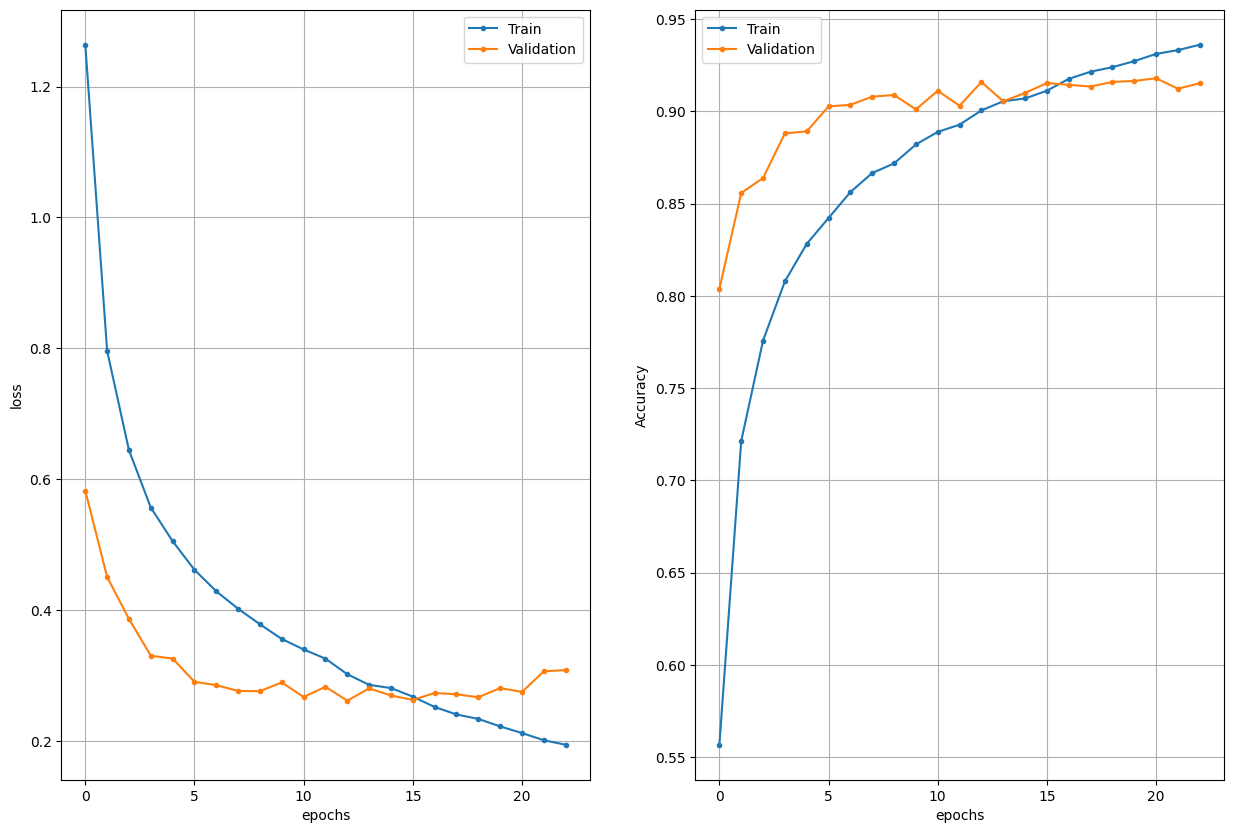

In [10]:
# Show the results

# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Questions

* What have you done in order to improve the performance?
* Have you tried configurations that did not work out?